In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from tqdm import tqdm

from scipy.signal import find_peaks
from scipy.stats import zscore

from stresscam.preprocessing.face_detection import FaceDetector
from stresscam.preprocessing.skin_segmentation import SkinSegmenter
from stresscam.preprocessing.rgb_extraction import RGBExtractor

from stresscam.rppg.pos import pos

In [17]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [18]:
detector = FaceDetector()

segmenter = SkinSegmenter()

extractor = RGBExtractor()

In [ ]:
video_path = (
    project_root
    / "data"
    / "raw"
    / "UBFC_Phys"
    / "s46"
    / "vid_s46_T1.avi"
)

cap = cv2.VideoCapture(str(video_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(fps)
print(cap.isOpened())

35.138
True


In [20]:
rgb_trace = []

failed = 0
processed = 0

pbar = tqdm(
    total=n_frames, 
    desc="Processing frames", 
    unit="frames", 
    ncols=100,
    colour="green"
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Face Detection
    det_results = detector.detect(frame)

    face = detector.crop(frame, det_results)

    if face is None:
        failed += 1
        continue

    # Face Mesh
    mask, mesh_results = segmenter.segment(face)

    if mask is None:
        failed += 1
        continue

    # RGB Extraction
    rgb = extractor.extract(face, mask)

    rgb_trace.append(rgb)

    processed += 1
    
    pbar.update(1)

pbar.close()
cap.release()

rgb_trace = np.array(rgb_trace)

print(rgb_trace.shape)
print("Processed:", processed)
print("Failed:", failed)

Processing frames:   0%|                                               | 0/6325 [00:00<?, ?frames/s]c:\Users\lason\.conda\envs\stresscam\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Processing frames: 100%|████████████████████████████████████| 6325/6325 [03:50<00:00, 27.42frames/s]

(6325, 3)
Processed: 6325
Failed: 0


In [28]:
R = rgb_trace[:, 0]
G = rgb_trace[:, 1]
B = rgb_trace[:, 2]
t = np.arange(len(R)) / fps

In [29]:
pulse = pos(rgb_trace, fps)

In [30]:
bvp_path = (
    project_root
    / "data"
    / "raw"
    / "UBFC_Phys"
    / "s46"
    / "bvp_s46_T1.csv"
)

bvp = np.loadtxt(bvp_path)

In [53]:
from scipy.signal import find_peaks

distance = int(0.4 * fps)      # max HR ≈150 BPM

peaks, properties = find_peaks(
    pulse,
    prominence = 0.001,
    distance = int(0.5 * fps)     # ~120 BPM max
)

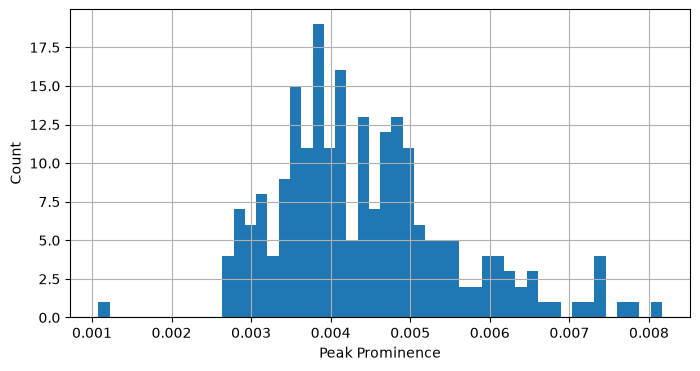

In [54]:
plt.figure(figsize=(8,4))
plt.hist(properties["prominences"], bins=50)
plt.xlabel("Peak Prominence")
plt.ylabel("Count")
plt.grid(True)
plt.show()

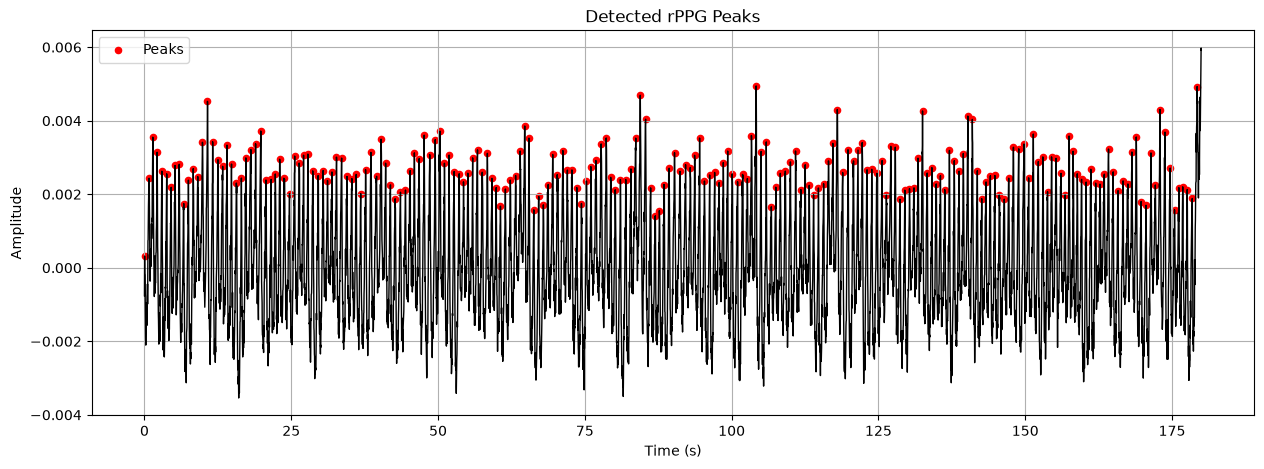

In [55]:
plt.figure(figsize=(15,5))

plt.plot(t, pulse, color="black", linewidth=1)

plt.scatter(
    t[peaks],
    pulse[peaks],
    color="red",
    s=20,
    label="Peaks",
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Detected rPPG Peaks")

plt.grid(True)
plt.legend()

plt.show()

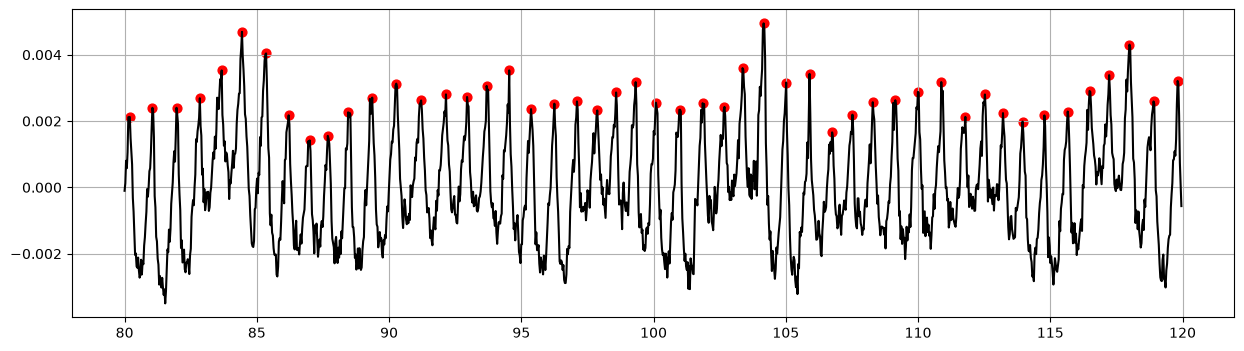

In [66]:
start_sec = 80
duration = 40

start = int(start_sec * fps)
end = int((start_sec + duration) * fps)

plt.figure(figsize=(15,4))
plt.plot(t[start:end], pulse[start:end], color="black")
plt.scatter(
    t[peaks[(peaks >= start) & (peaks < end)]],
    pulse[peaks[(peaks >= start) & (peaks < end)]],
    color="red",
    s=40,
)
plt.grid(True)
plt.show()

In [67]:
# Peak times (seconds)
peak_times = peaks / fps

# Inter-beat intervals (seconds)
ibi = np.diff(peak_times)

print(f"Detected peaks : {len(peaks)}")
print(f"Mean IBI       : {np.mean(ibi):.3f} s")

Detected peaks : 224
Mean IBI       : 0.804 s


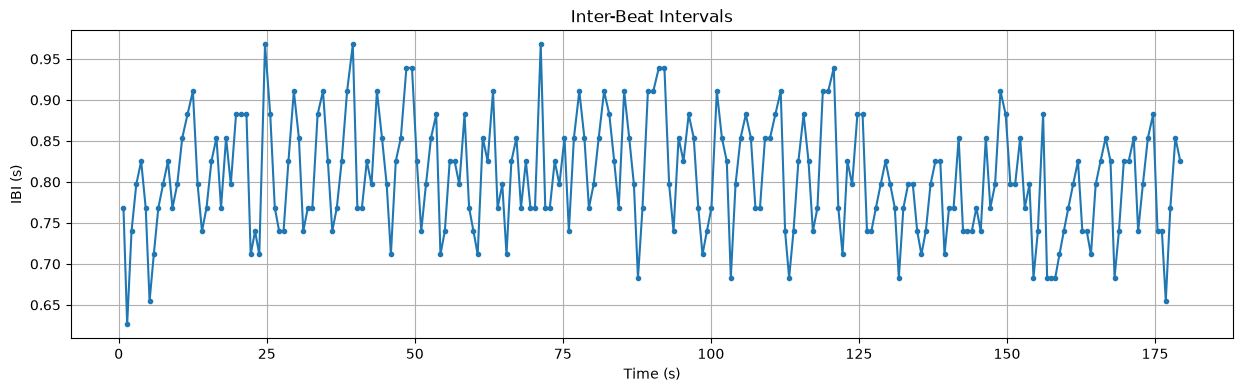

In [68]:
plt.figure(figsize=(15,4))

plt.plot(
    peak_times[1:],
    ibi,
    marker="o",
    markersize=3,
)

plt.xlabel("Time (s)")
plt.ylabel("IBI (s)")
plt.title("Inter-Beat Intervals")

plt.grid(True)

plt.show()

In [69]:
# Instantaneous HR
hr = 60 / ibi

print(f"Mean HR : {np.mean(hr):.2f} BPM")
print(f"Min HR  : {np.min(hr):.2f} BPM")
print(f"Max HR  : {np.max(hr):.2f} BPM")

Mean HR : 75.20 BPM
Min HR  : 62.01 BPM
Max HR  : 95.83 BPM


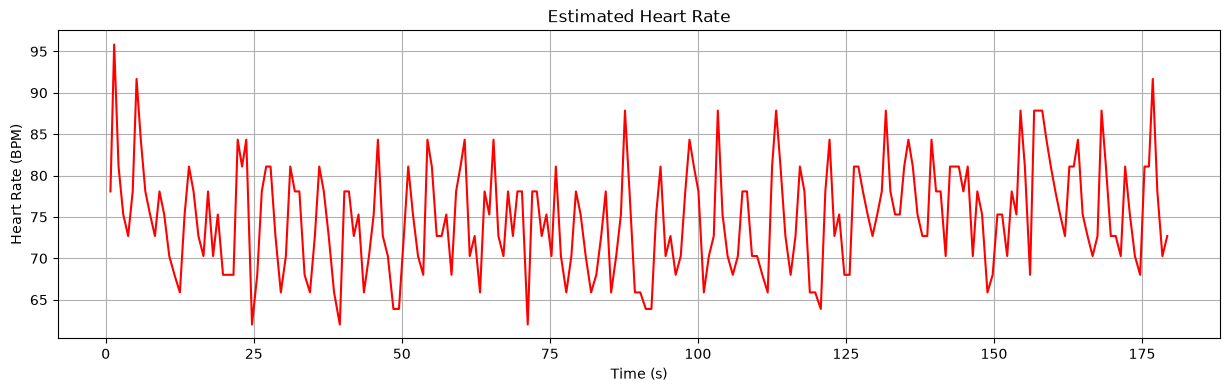

In [70]:
plt.figure(figsize=(15,4))

plt.plot(
    peak_times[1:],
    hr,
    color="red",
)

plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Estimated Heart Rate")

plt.grid(True)

plt.show()

In [71]:
mean_ibi = np.mean(ibi)

mean_hr = np.mean(hr)

sdnn = np.std(ibi, ddof=1)

rmssd = np.sqrt(np.mean(np.diff(ibi) ** 2))

nn50 = np.sum(np.abs(np.diff(ibi)) > 0.05)

pnn50 = 100 * nn50 / len(np.diff(ibi))

print(f"Mean HR : {mean_hr:.2f} BPM")
print(f"Mean IBI: {mean_ibi:.3f} s")
print(f"SDNN    : {sdnn:.4f} s")
print(f"RMSSD   : {rmssd:.4f} s")
print(f"NN50    : {nn50}")
print(f"pNN50   : {pnn50:.2f} %")

Mean HR : 75.20 BPM
Mean IBI: 0.804 s
SDNN    : 0.0687 s
RMSSD   : 0.0789 s
NN50    : 129
pNN50   : 58.11 %


### Detect BVP Peaks

In [73]:
print(bvp.shape)
print(len(pulse))

(11520,)
6325


In [74]:
from scipy.signal import resample

bvp_resampled = resample(bvp, len(pulse))

print(len(bvp_resampled))

6325


In [75]:
from scipy.signal import find_peaks

bvp_peaks, _ = find_peaks(
    bvp_resampled,
    distance=int(0.5 * fps),
    prominence=0.2,
)

In [76]:
bvp_peak_times = bvp_peaks / fps

bvp_ibi = np.diff(bvp_peak_times)

bvp_hr = 60 / bvp_ibi

gt_features = {
    "Mean HR": np.mean(bvp_hr),
    "Mean IBI": np.mean(bvp_ibi),
    "SDNN": np.std(bvp_ibi, ddof=1),
    "RMSSD": np.sqrt(np.mean(np.diff(bvp_ibi) ** 2)),
}

nn50 = np.sum(np.abs(np.diff(bvp_ibi)) > 0.05)
gt_features["pNN50"] = 100 * nn50 / len(np.diff(bvp_ibi))

In [77]:
our_features = {
    "Mean HR": mean_hr,
    "Mean IBI": mean_ibi,
    "SDNN": sdnn,
    "RMSSD": rmssd,
    "pNN50": pnn50,
}

print(f"{'Feature':<12} {'rPPG':>12} {'Ground Truth':>15}")

for key in our_features:
    print(
        f"{key:<12}"
        f"{our_features[key]:>12.3f}"
        f"{gt_features[key]:>15.3f}"
    )

Feature              rPPG    Ground Truth
Mean HR           75.197         75.249
Mean IBI           0.804          0.804
SDNN               0.069          0.077
RMSSD              0.079          0.108
pNN50             58.108         55.856


In [78]:
import pandas as pd

comparison = pd.DataFrame({
    "Feature": ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"],
    "rPPG": [
        mean_hr,
        mean_ibi,
        sdnn,
        rmssd,
        pnn50,
    ],
    "Ground Truth": [
        gt_features["Mean HR"],
        gt_features["Mean IBI"],
        gt_features["SDNN"],
        gt_features["RMSSD"],
        gt_features["pNN50"],
    ],
})

comparison["Absolute Error"] = (
    comparison["rPPG"] - comparison["Ground Truth"]
).abs()

comparison

,Feature,rPPG,Ground Truth,Absolute Error
0,Mean HR,75.196575,75.249235,0.052660
1,Mean IBI,0.803750,0.804132,0.000383
2,SDNN,0.068680,0.077362,0.008681
3,RMSSD,0.078939,0.108470,0.029532
4,pNN50,58.108108,55.855856,2.252252
